In [ ]:
import pandas as pd

# Upload the eigengene CSV to Colab or mount Google Drive as needed
eigengene_file = '/content/Supplementary Material S4_Eigengene_TCGA-BRCA.csv'

# Load the eigengene matrix
# First, ltry loading without header to inspect shape and orientation
eigengenes = pd.read_csv(eigengene_file, index_col=0)
print("Shape of eigengene matrix:", eigengenes.shape)
print("First 5 rows:")
print(eigengenes.head())

# View column and index names (samples/modules)
print("Column names (samples):", eigengenes.columns[:5])
print("Row index (should be eigengene modules):", eigengenes.index[:5])

Shape of eigengene matrix: (42, 1076)
First 5 rows:
     TCGA-3C-AAAU  TCGA-3C-AALI  TCGA-3C-AALJ  TCGA-3C-AALK  TCGA-4H-AAAK  \
ME0  2.750000e-06 -3.720000e-07      0.000009  5.700000e-07  2.150000e-07   
ME1  6.104660e-04  7.037588e-03     -0.005548  5.965112e-03 -2.022673e-02   
ME2 -8.880521e-03 -8.675365e-03     -0.017807  1.353157e-02  7.458414e-03   
ME3 -2.240295e-02  1.457150e-02     -0.003986  9.609710e-03  4.248445e-02   
ME4 -8.210000e-08  8.796776e-03     -0.004462 -1.928918e-02 -1.181356e-02   

     TCGA-5L-AAT0  TCGA-5T-A9QA  TCGA-A1-A0SB  TCGA-A1-A0SD  TCGA-A1-A0SE  \
ME0     -0.000008      0.000004  9.720000e-07     -0.000007     -0.000003   
ME1     -0.009778      0.004641 -3.612803e-02     -0.043557     -0.007069   
ME2     -0.005082     -0.012687 -2.163396e-03      0.000077     -0.018316   
ME3     -0.011925      0.050145 -7.972219e-03     -0.014550     -0.015674   
ME4     -0.019093      0.001374 -9.961305e-03     -0.014283      0.000429   

     ...  TCGA-UL-AAZ6

In [2]:
# Transpose so samples are rows, features (modules) are columns
eigengenes_t = eigengenes.T
print("After transpose: Rows = samples, Columns = modules")
print("Shape:", eigengenes_t.shape)

# Preview the data (samples × modules)
print(eigengenes_t.head())

# Save for further integration steps
eigengene_df = eigengenes_t


After transpose: Rows = samples, Columns = modules
Shape: (1076, 42)
                       ME0       ME1       ME2       ME3           ME4  \
TCGA-3C-AAAU  2.750000e-06  0.000610 -0.008881 -0.022403 -8.210000e-08   
TCGA-3C-AALI -3.720000e-07  0.007038 -0.008675  0.014571  8.796776e-03   
TCGA-3C-AALJ  9.360000e-06 -0.005548 -0.017807 -0.003986 -4.462258e-03   
TCGA-3C-AALK  5.700000e-07  0.005965  0.013532  0.009610 -1.928918e-02   
TCGA-4H-AAAK  2.150000e-07 -0.020227  0.007458  0.042484 -1.181356e-02   

                   ME5       ME6       ME7       ME8       ME9  ...      ME32  \
TCGA-3C-AAAU -0.005362 -0.003461 -0.002339  0.014500 -0.023676  ... -0.016042   
TCGA-3C-AALI  0.004431  0.000698  0.106472 -0.021435 -0.006398  ... -0.003757   
TCGA-3C-AALJ -0.009693 -0.002422  0.021433 -0.025018 -0.009693  ...  0.049149   
TCGA-3C-AALK  0.008379 -0.002596 -0.022996  0.036858  0.031875  ...  0.012983   
TCGA-4H-AAAK  0.000683  0.000619  0.021428 -0.026555  0.014352  ... -0.021635   


In [3]:
# Remove all columns that are not eigengene modules (drop NaN columns)
eigengene_df = eigengene_df.loc[:, ~eigengene_df.columns.str.startswith('NaN', na=False)]

# Or more generally, drop all columns with any NaNs (since blank columns should be dropped)
eigengene_df = eigengene_df.dropna(axis=1, how='all')

# Clean up extraneous columns names if needed
eigengene_df = eigengene_df.loc[:, eigengene_df.columns.str.startswith('ME')]

# Check result
print("Cleaned eigengene features shape (samples × modules):", eigengene_df.shape)
print(eigengene_df.head())

# Check if any missing values remain:
print("Any missing values in eigengene_df?", eigengene_df.isnull().values.any())

# Optional: Fill missing module values with mean/module (if needed for ML)
eigengene_df = eigengene_df.fillna(eigengene_df.mean())


Cleaned eigengene features shape (samples × modules): (1076, 40)
                       ME0       ME1       ME2       ME3           ME4  \
TCGA-3C-AAAU  2.750000e-06  0.000610 -0.008881 -0.022403 -8.210000e-08   
TCGA-3C-AALI -3.720000e-07  0.007038 -0.008675  0.014571  8.796776e-03   
TCGA-3C-AALJ  9.360000e-06 -0.005548 -0.017807 -0.003986 -4.462258e-03   
TCGA-3C-AALK  5.700000e-07  0.005965  0.013532  0.009610 -1.928918e-02   
TCGA-4H-AAAK  2.150000e-07 -0.020227  0.007458  0.042484 -1.181356e-02   

                   ME5       ME6       ME7       ME8       ME9  ...      ME30  \
TCGA-3C-AAAU -0.005362 -0.003461 -0.002339  0.014500 -0.023676  ... -0.024856   
TCGA-3C-AALI  0.004431  0.000698  0.106472 -0.021435 -0.006398  ...  0.037332   
TCGA-3C-AALJ -0.009693 -0.002422  0.021433 -0.025018 -0.009693  ... -0.024879   
TCGA-3C-AALK  0.008379 -0.002596 -0.022996  0.036858  0.031875  ...  0.043061   
TCGA-4H-AAAK  0.000683  0.000619  0.021428 -0.026555  0.014352  ...  0.006790   

   

In [4]:
# 1. Load
metabric_eigengenes = pd.read_csv('Supplementary Material S5_Eigengene_METABRIC.csv', index_col=0)

# 2. Transpose for ML (samples = rows)
metabric_eigengenes_t = metabric_eigengenes.T

# 3. Clean: drop any all-NaN columns, keep only ME columns
metabric_eigengene_df = metabric_eigengenes_t.dropna(axis=1, how='all')
metabric_eigengene_df = metabric_eigengene_df.loc[:, metabric_eigengene_df.columns.str.startswith('ME')]

# Check result
print("METABRIC eigengene shape:", metabric_eigengene_df.shape)
print(metabric_eigengene_df.head())

# Check missing data
print("Any missing values in metabric_eigengene_df?", metabric_eigengene_df.isnull().values.any())

# Optional: Fill NAs if any
metabric_eigengene_df = metabric_eigengene_df.fillna(metabric_eigengene_df.mean())


METABRIC eigengene shape: (1378, 49)
              ME0       ME1       ME2       ME3       ME4       ME5       ME6  \
MB.2747 -0.031127 -0.028100 -0.019005  0.012901  0.031768 -0.022483  0.017112   
MB.0384 -0.032660 -0.020428 -0.009246  0.023535  0.017409 -0.003785  0.009947   
MB.6103  0.002893 -0.006850  0.009974  0.018859  0.008721 -0.025166  0.003239   
MB.7254 -0.004132 -0.005251 -0.029388  0.010663  0.009912 -0.011065  0.011759   
MB.4709  0.017131  0.011446 -0.024468 -0.016233 -0.010363 -0.021819  0.018419   

              ME7       ME8       ME9  ...      ME39      ME40      ME41  \
MB.2747  0.016905 -0.004060  0.014998  ... -0.019132 -0.017013  0.016817   
MB.0384  0.013330 -0.008304  0.046196  ... -0.006175 -0.029294  0.022816   
MB.6103 -0.009913  0.012746 -0.024052  ... -0.020546 -0.008812  0.013402   
MB.7254  0.006336  0.005835 -0.017392  ... -0.017944 -0.001456  0.008519   
MB.4709  0.011232 -0.003083 -0.018625  ...  0.019158 -0.010306 -0.007825   

             ME42  

In [5]:
from sklearn.preprocessing import StandardScaler

# TCGA normalization
scaler_tcga = StandardScaler()
eigengene_tcga_scaled = pd.DataFrame(
    scaler_tcga.fit_transform(eigengene_df),
    index=eigengene_df.index,
    columns=eigengene_df.columns
)

# METABRIC normalization
scaler_metabric = StandardScaler()
metabric_eigengene_scaled = pd.DataFrame(
    scaler_metabric.fit_transform(metabric_eigengene_df),
    index=metabric_eigengene_df.index,
    columns=metabric_eigengene_df.columns
)


In [6]:
# Find modules (columns) present in both datasets
common_modules = eigengene_tcga_scaled.columns.intersection(metabric_eigengene_scaled.columns)

# Keep only these in both frames
tcga_common = eigengene_tcga_scaled[common_modules]
metabric_common = metabric_eigengene_scaled[common_modules]

# Tag cohort for downstream visualization
tcga_common.loc[:, 'cohort'] = 'TCGA'
metabric_common.loc[:, 'cohort'] = 'METABRIC'

# Stack the datasets (samples × common_features+cohort)
integrated_eigengenes = pd.concat([tcga_common, metabric_common], axis=0)
print("Integrated shape:", integrated_eigengenes.shape)
print(integrated_eigengenes['cohort'].value_counts())
print(integrated_eigengenes.head())


Integrated shape: (2454, 41)
cohort
METABRIC    1378
TCGA        1076
Name: count, dtype: int64
                   ME0       ME1       ME2       ME3       ME4       ME5  \
TCGA-3C-AAAU  0.049338  0.018825 -0.309529 -0.778036 -0.017090 -0.197343   
TCGA-3C-AALI -0.006268  0.240127 -0.302435  0.500683  0.284686  0.143106   
TCGA-3C-AALJ  0.167069 -0.193221 -0.618210 -0.141099 -0.170165 -0.347891   
TCGA-3C-AALK  0.010510  0.203198  0.465461  0.329085 -0.678801  0.280336   
TCGA-4H-AAAK  0.004187 -0.698652  0.255457  1.466021 -0.422351  0.012801   

                   ME6       ME7       ME8       ME9  ...      ME31      ME32  \
TCGA-3C-AAAU -0.121629 -0.107980  0.512661 -0.816167  ... -0.695531 -0.550196   
TCGA-3C-AALI  0.015023  3.586813 -0.726464 -0.214927  ... -0.342448 -0.129624   
TCGA-3C-AALJ -0.087499  0.699213 -0.850010 -0.329583  ... -0.396585  1.681555   
TCGA-3C-AALK -0.093220 -0.809398  1.283578  1.116881  ... -0.000607  0.443433   
TCGA-4H-AAAK  0.012404  0.699057 -0.903016

/tmp/ipython-input-2575679165.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metabric_common.loc[:, 'cohort'] = 'METABRIC'


Graph constructed: 36810 edges for 2454 samples.


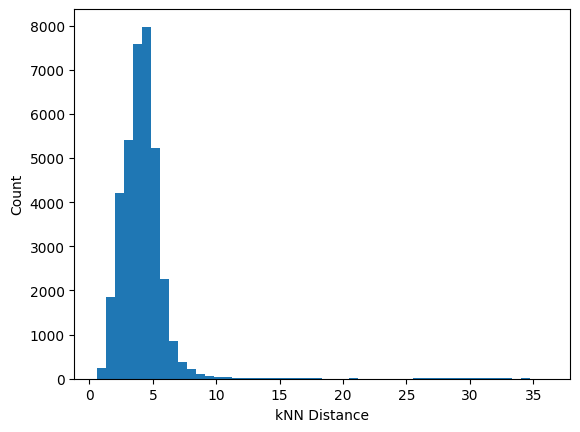

In [7]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Drop cohort indicator for numerical embedding/graph
X_numeric = integrated_eigengenes.drop(columns=['cohort']).values

# Set k for kNN graph
k = 15

# Compute kNN for all samples
knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean').fit(X_numeric)
distances, neighbors = knn.kneighbors(X_numeric)

# Remove self-loops (first neighbor is always itself)
edges = []
for i in range(neighbors.shape[0]):
    for j in range(1, k + 1):
        edges.append((i, neighbors[i, j]))

edges = np.array(edges)
print(f"Graph constructed: {len(edges)} edges for {X_numeric.shape[0]} samples.")

# Optional: kNN distance histogram
import matplotlib.pyplot as plt
plt.hist(distances[:,1:].flatten(), bins=50)
plt.xlabel('kNN Distance')
plt.ylabel('Count')
plt.show()



In [8]:
# !pip install torch-scatter torch-sparse torch-geometric

In [9]:
import torch
from torch_geometric.data import Data

# X_numeric: your (2454, 40) feature numpy array (excluding 'cohort')
# edges: (num_edges, 2) numpy array from the kNN construction

# Convert to tensors
X_tensor = torch.tensor(X_numeric, dtype=torch.float)
edge_index = torch.tensor(edges.T, dtype=torch.long)  # shape (2, num_edges)

# PyG Data object (you can add 'cohort' if needed for visualization/supervision)
data = Data(x=X_tensor, edge_index=edge_index)
print(data)

# Optional: Attach cohort to data
cohort_labels = integrated_eigengenes['cohort'].apply(lambda x: 0 if x=='TCGA' else 1).values
data.cohort = torch.tensor(cohort_labels, dtype=torch.long)


Data(x=[2454, 40], edge_index=[2, 36810])


In [10]:
import torch
from torch_geometric.data import Data

# X_numeric: your (2454, 40) feature numpy array (excluding 'cohort')
# edges: (num_edges, 2) numpy array from the kNN construction

# Convert to tensors
X_tensor = torch.tensor(X_numeric, dtype=torch.float)
edge_index = torch.tensor(edges.T, dtype=torch.long)  # shape (2, num_edges)

# PyG Data object (you can add 'cohort' if needed for visualization/supervision)
data = Data(x=X_tensor, edge_index=edge_index)
print(data)

# Optional: Attach cohort to data
cohort_labels = integrated_eigengenes['cohort'].apply(lambda x: 0 if x=='TCGA' else 1).values
data.cohort = torch.tensor(cohort_labels, dtype=torch.long)


Data(x=[2454, 40], edge_index=[2, 36810])


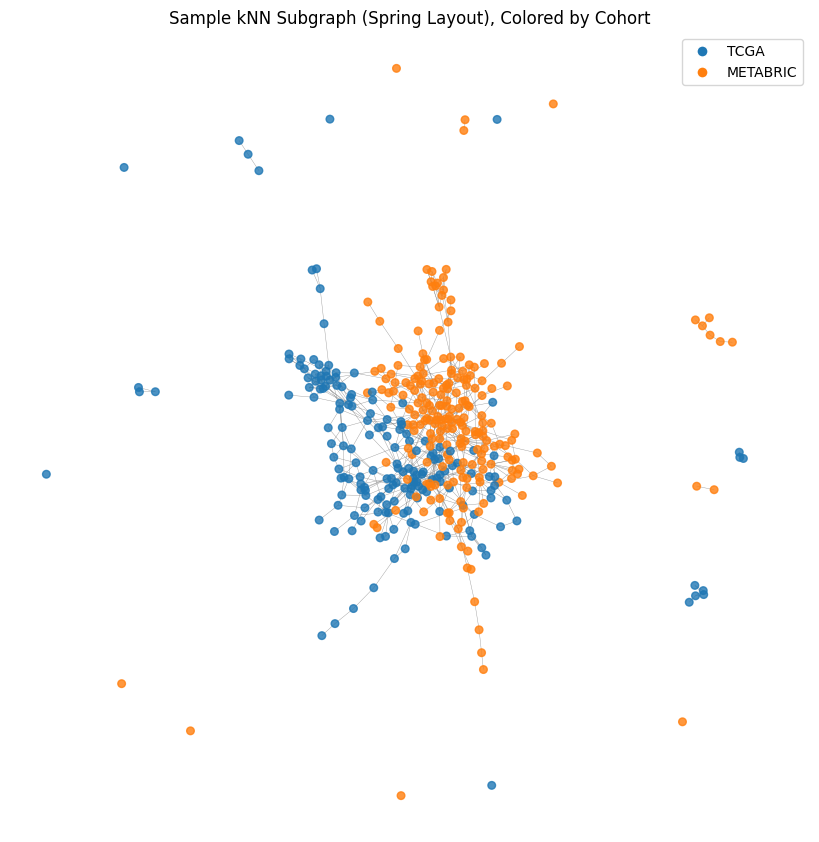

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.Graph()
G.add_edges_from(edges)

np.random.seed(0)
sub_nodes = np.random.choice(G.nodes, 400, replace=False)
H = G.subgraph(sub_nodes)

color_map = {'TCGA': 'tab:blue', 'METABRIC': 'tab:orange'}

# Use integer-based indexing!
node_colors = [color_map[integrated_eigengenes.iloc[n]['cohort']] for n in H.nodes]

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(H, seed=42)
nx.draw(
    H, pos, node_color=node_colors,
    node_size=30, alpha=0.8, edge_color='gray', width=0.3, with_labels=False
)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markersize=8)
    for k, v in color_map.items()
]
plt.legend(handles=handles)
plt.title("Sample kNN Subgraph (Spring Layout), Colored by Cohort")
plt.show()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


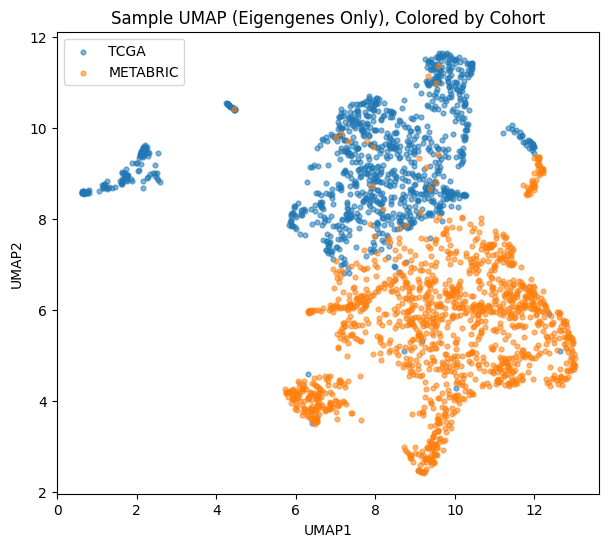

In [12]:
import umap
import matplotlib.pyplot as plt

X_features = integrated_eigengenes.drop(columns=['cohort']).values
embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_features)

plt.figure(figsize=(7,6))
for cohort, color in color_map.items():
    idx = integrated_eigengenes['cohort'] == cohort
    plt.scatter(embedding[idx,0], embedding[idx,1], c=color, label=cohort, s=12, alpha=0.55)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Sample UMAP (Eigengenes Only), Colored by Cohort")
plt.legend()
plt.show()


In [36]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, VGAE

# VGAE Encoder definition
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 32)
        self.conv_mu = GCNConv(32, out_channels)
        self.conv_logvar = GCNConv(32, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# Select your latent embedding size
latent_dim = 24

# Build the VGAE model
model = VGAE(GCNEncoder(data.x.shape[1], latent_dim))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# VGAE training loop
model.train()
for epoch in range(1, 201):
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.edge_index)
    loss = loss + (1 / data.num_nodes) * model.kl_loss()
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Switch to eval mode and encode final graph embeddings
model.eval()
embeddings = model.encode(data.x, data.edge_index).detach().cpu().numpy()
print("Graph embeddings shape:", embeddings.shape)


Epoch 1, Loss: 1334.1243
Epoch 20, Loss: 2.8944
Epoch 40, Loss: 1.5928
Epoch 60, Loss: 1.3156
Epoch 80, Loss: 1.2176
Epoch 100, Loss: 1.1292
Epoch 120, Loss: 1.1098
Epoch 140, Loss: 1.0801
Epoch 160, Loss: 1.0600
Epoch 180, Loss: 1.0472
Epoch 200, Loss: 1.0219
Graph embeddings shape: (2454, 24)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


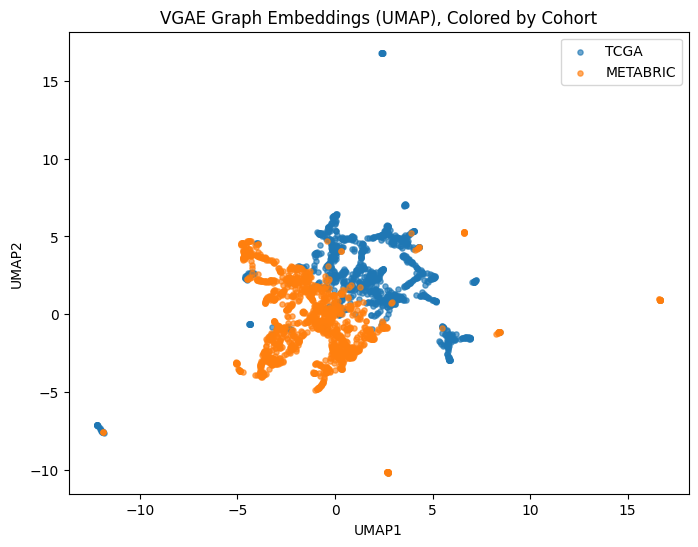

In [38]:
import umap
import matplotlib.pyplot as plt

color_map = {'TCGA': 'tab:blue', 'METABRIC': 'tab:orange'}
umap_embed = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(embeddings)

plt.figure(figsize=(8,6))
for cohort, color in color_map.items():
    idx = integrated_eigengenes['cohort'] == cohort
    plt.scatter(umap_embed[idx,0], umap_embed[idx,1], c=color, label=cohort, s=14, alpha=0.65)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("VGAE Graph Embeddings (UMAP), Colored by Cohort")
plt.legend()
plt.show()


In [39]:
from sklearn.cluster import KMeans

# Choose number of clusters (can experiment: 5–8 is typical if unknown)
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)


In [40]:
# Add clustering result to the integrated_eigengenes DataFrame
integrated_eigengenes['cluster'] = cluster_labels


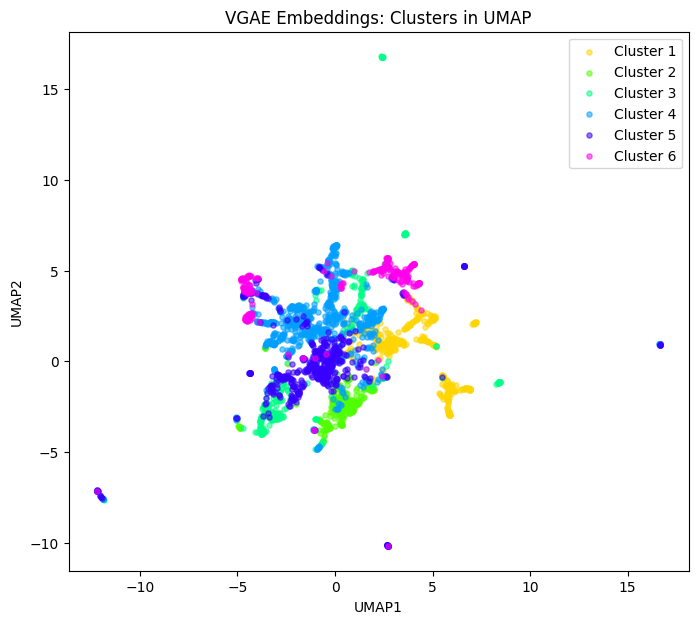

In [41]:
import matplotlib.pyplot as plt

# Assign distinct colors for clusters
import seaborn as sns
palette = sns.color_palette("hsv", n_clusters)

plt.figure(figsize=(8,7))
for i in range(n_clusters):
    idx = (cluster_labels == i)
    plt.scatter(umap_embed[idx,0], umap_embed[idx,1],
                s=14, label=f"Cluster {i+1}", alpha=0.55, color=palette[i])
plt.title("VGAE Embeddings: Clusters in UMAP")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.show()


In [42]:
# Table: samples per [cluster × cohort]
crosstab = pd.crosstab(integrated_eigengenes['cluster'], integrated_eigengenes['cohort'])
print("Cluster × Cohort table:\n", crosstab)


Cluster × Cohort table:
 cohort   METABRIC  TCGA
cluster                
0              33   354
1             258     3
2             206   130
3             391   345
4             421    79
5              69   165


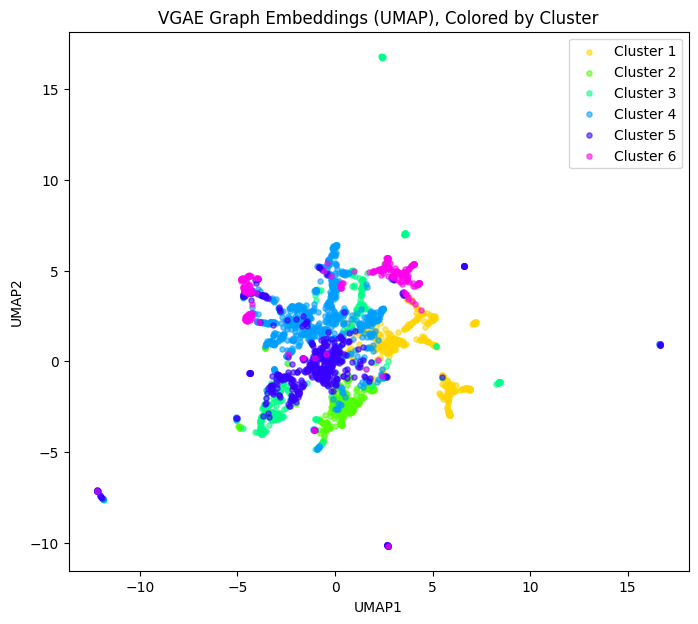

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Uses UMAP projection computed earlier: umap_embed
# Uses cluster labels: integrated_eigengenes['cluster']

n_clusters = integrated_eigengenes['cluster'].nunique()
palette = sns.color_palette("hsv", n_clusters)

plt.figure(figsize=(8,7))
for i in range(n_clusters):
    idx = (integrated_eigengenes['cluster'] == i)
    plt.scatter(umap_embed[idx,0], umap_embed[idx,1],
                s=14, label=f"Cluster {i+1}", alpha=0.58, color=palette[i])
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("VGAE Graph Embeddings (UMAP), Colored by Cluster")
plt.legend()
plt.show()


In [44]:
import pandas as pd
from scipy.stats import kruskal

eigengene_cols = [col for col in integrated_eigengenes.columns if col.startswith('ME')]

# Store p-values
kruskal_pvals = {}

for col in eigengene_cols:
    groups = [integrated_eigengenes.loc[integrated_eigengenes['cluster'] == c, col]
              for c in integrated_eigengenes['cluster'].unique()]
    stat, p = kruskal(*groups)
    kruskal_pvals[col] = p

# Sort modules by P-value (lowest = strongest evidence for cluster difference)
marker_df = pd.DataFrame.from_dict(kruskal_pvals, orient='index', columns=['kruskal_p'])
marker_df = marker_df.sort_values('kruskal_p')
print(marker_df.head(10))


          kruskal_p
ME5   1.497519e-164
ME13  4.127978e-146
ME8   4.662258e-131
ME25  2.419751e-126
ME38  5.760411e-126
ME20  1.128850e-124
ME10  3.814303e-124
ME11  1.200814e-120
ME31  2.481924e-120
ME4   3.269236e-108


In [45]:
# Top N modules with lowest p-values
top_n = 5
top_markers = marker_df.head(top_n).index.tolist()

# Show per-cluster median for these markers
cluster_groups = integrated_eigengenes.groupby('cluster')[top_markers].median().T
print(cluster_groups)


cluster         0         1         2         3         4         5
ME5     -0.193288 -0.821269  0.439873 -0.310591  0.413539 -0.208363
ME13     0.037818  0.894185 -0.396748 -0.030113 -0.164248 -0.123470
ME8     -0.500268  0.977535  0.450081  0.110444 -0.512997 -0.687241
ME25    -0.119815 -0.856472  0.076537 -0.206480  0.258968  0.079714
ME38    -0.081742 -0.925623 -0.123674 -0.196933  0.141202  0.196788


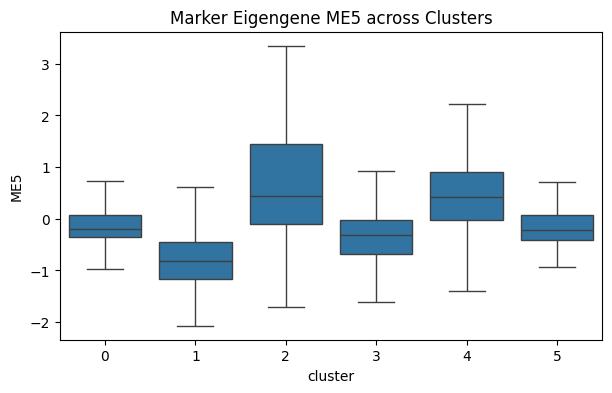

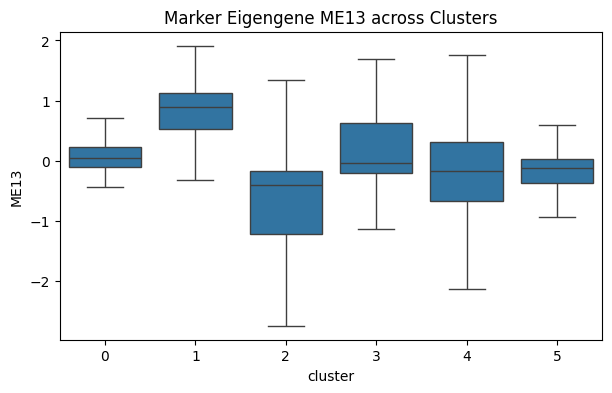

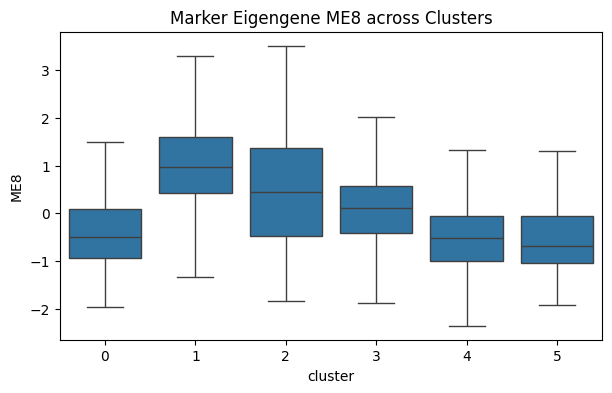

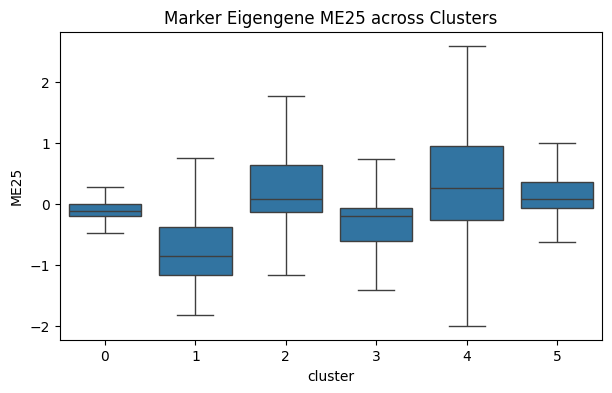

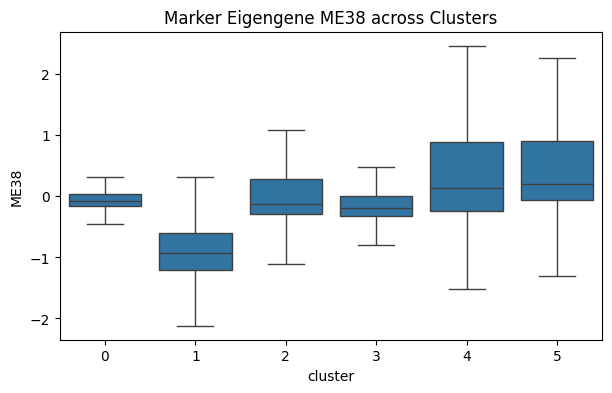

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

for marker in top_markers:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='cluster', y=marker, data=integrated_eigengenes, showfliers=False)
    plt.title(f'Marker Eigengene {marker} across Clusters')
    plt.show()



In [47]:
from sklearn.metrics import silhouette_score
score = silhouette_score(embeddings, integrated_eigengenes['cluster'])
print(f"Silhouette score of clustering: {score:.3f}")


Silhouette score of clustering: 0.087


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Encode cohort as 0/1: METABRIC = 1, TCGA = 0
labels = (integrated_eigengenes['cohort'] == 'METABRIC').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.3, random_state=42, stratify=labels)
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Cohort prediction accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC (cohort as label):", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))


Cohort prediction accuracy: 0.8683853459972863
ROC AUC (cohort as label): 0.9381926683716966


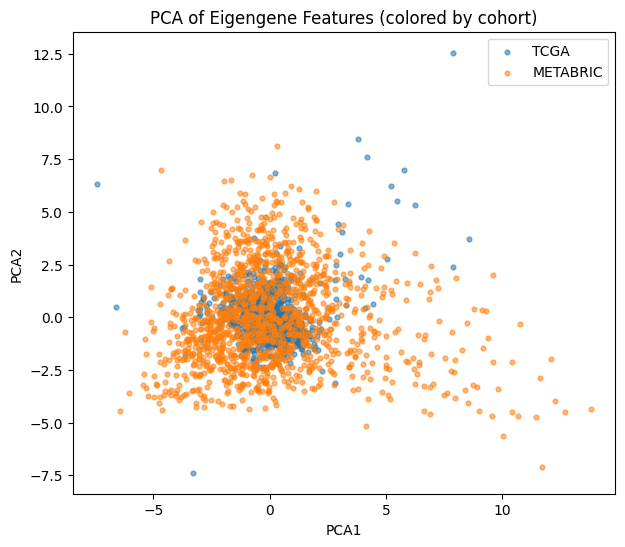

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
eigengene_cols = [col for col in integrated_eigengenes.columns if col.startswith('ME')]
pca_proj = pca.fit_transform(integrated_eigengenes[eigengene_cols].values)

# Plot by cohort
plt.figure(figsize=(7,6))
for cohort, color in {'TCGA': 'tab:blue', 'METABRIC': 'tab:orange'}.items():
    idx = (integrated_eigengenes['cohort'] == cohort)
    plt.scatter(pca_proj[idx,0], pca_proj[idx,1], c=color, label=cohort, s=12, alpha=0.55)
plt.xlabel("PCA1"); plt.ylabel("PCA2")
plt.title("PCA of Eigengene Features (colored by cohort)")
plt.legend(); plt.show()
